In [ ]:
# iris 붓꽃 데이터 불러오기 - 붓꽃 품종이 두개로 되있는 데이터
from sklearn.datasets import load_iris
iris = load_iris()

# 불러온 데이터가 무엇을 가지고있는 지 알아보기
print(iris.keys())
# data, target, feature_names, target_names 있는 것을 확인

# 활동예제 ->
# 붗꽃 품종을 분류하는 모델
# SVM 과 KNN 으로
# 학습 결과를 시각화하기

x = iris.data
y = iris.target

# 데이터 상태 확인 및 결측치, 데이터 전처리 안해도 되나?

# 데이터 분리
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

# 모델 생성에 필요한 라이브러리 불러오기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC # ^

# SVM 모델 생성, KNN 모델 생성
knn = KNeighborsClassifier()
svm = SVC()

# 모델 학습
knn.fit(x_train,y_train)
svm.fit(x_train,y_train)

# 예측
knn_predict = knn.predict(x_test)
svm_predict = svm.predict(x_test)

# 리포트
from sklearn.metrics import classification_report
print(classification_report(y_test,knn_predict))
print(classification_report(y_test,svm_predict))

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
# 데이터 누수 현상 발생 -> 스케일링 추가

In [ ]:
# iris 붓꽃 데이터 불러오기 - 붓꽃 품종이 두개로 되있는 데이터
from sklearn.datasets import load_iris
iris = load_iris()

# 불러온 데이터가 무엇을 가지고있는 지 알아보기
print(iris.keys())
# data, target, feature_names, target_names 있는 것을 확인

# 활동예제 ->
# 붗꽃 품종을 분류하는 모델
# SVM 과 KNN 으로
# 학습 결과를 시각화하기

x = iris.data
y = iris.target

# 데이터 상태 확인 및 결측치, 데이터 전처리 안해도 되나?

# 데이터 분리
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
# x_train 과 x_test에만 스케일링을 적용하는 이유 ^ test 데이터 형식을 x_train과 맞추기 위해서 transform 사용

# 모델 생성에 필요한 라이브러리 불러오기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC # ^

# SVM 모델 생성, KNN 모델 생성
knn = KNeighborsClassifier()
svm = SVC()

# 모델 학습
knn.fit(x_train,y_train)
svm.fit(x_train,y_train)

# 예측
knn_predict = knn.predict(x_test)
svm_predict = svm.predict(x_test)

# 리포트
from sklearn.metrics import classification_report
print(classification_report(y_test,knn_predict))
print(classification_report(y_test,svm_predict))

In [ ]:
# 시각화
# svm large 마진 - 가장 안정적으로 나눌 수 있는 최적의 경계선
from sklearn.svm import SVC
from sklearn.datasets import load_iris
import seaborn as sns
iris = load_iris()
X = iris.data[:,[2,3]] # 꽃잎의 길이, 너비
y = iris.target

# 품종은 setosa versicolor 0,1
mask = (y == 0) | (y == 1) # 합집합
X = X[mask]
y = y[mask]


# 선형으로 학습? ^
svm_clf = SVC(kernel='linear', C=float('inf'))
svm_clf.fit(X,y)
# 이렇게 설정하면 모든 데이터를 완벽하게 직선으로 나누려고 시도한다.

# C 는 규제 Regularization 마진을 얼마나 깨끗하게 유지할지 설정
# inf(무한대)로 설정, 마진오류 허용 X -> 하드 마진이라고 한다.

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


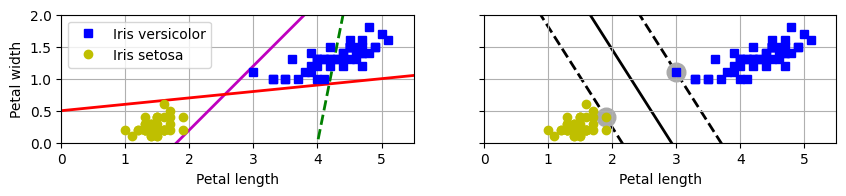

In [8]:
import numpy as np
from sklearn.svm import SVC
from sklearn import datasets
import matplotlib.pyplot as plt

iris = datasets.load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# SVM 분류 모델
svm_clf = SVC(kernel="linear", C=10**9)
svm_clf.fit(X, y)

# 나쁜 모델
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # 결정 경계에서, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

plt.sca(axes[1])
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
plt.xlabel("Petal length")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

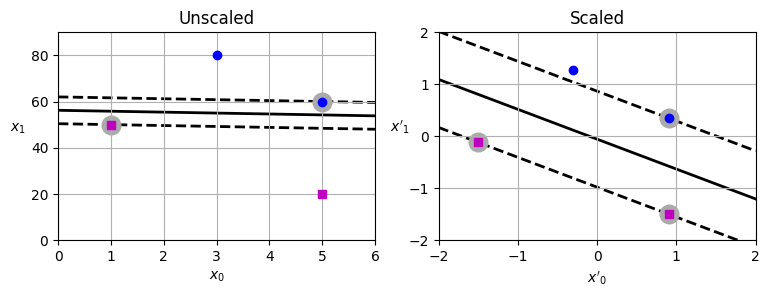

In [ ]:
# 스케일에 민감 ^ 뭐가? 마진 결정경계면의 위치가
# 스케일이 다른 가상의 데이터를생성
from sklearn.preprocessing import StandardScaler
Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
svm_clf = SVC(kernel="linear", C=100).fit(Xs, ys)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xs)
svm_clf_scaled = SVC(kernel="linear", C=100).fit(X_scaled, ys)

plt.figure(figsize=(9, 2.7))
plt.subplot(121)
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$")
plt.ylabel("$x_1$    ", rotation=0)
plt.title("Unscaled")
plt.axis([0, 6, 0, 90])
plt.grid()

plt.subplot(122)
plt.plot(X_scaled[:, 0][ys==1], X_scaled[:, 1][ys==1], "bo")
plt.plot(X_scaled[:, 0][ys==0], X_scaled[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf_scaled, -2, 2)
plt.xlabel("$x'_0$")
plt.ylabel("$x'_1$  ", rotation=0)
plt.title("Scaled")
plt.axis([-2, 2, -2, 2])
plt.grid()

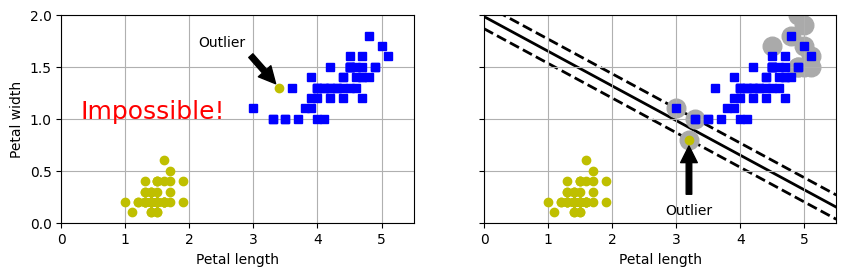

In [10]:
iris = datasets.load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

X_outliers = np.array([[3.4, 1.3], [3.2, 0.8]])
y_outliers = np.array([0, 0])
Xo1 = np.concatenate([X, X_outliers[:1]], axis=0)
yo1 = np.concatenate([y, y_outliers[:1]], axis=0)
Xo2 = np.concatenate([X, X_outliers[1:]], axis=0)
yo2 = np.concatenate([y, y_outliers[1:]], axis=0)

svm_clf2 = SVC(kernel="linear", C=10**9)
svm_clf2.fit(Xo2, yo2)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(Xo1[:, 0][yo1==1], Xo1[:, 1][yo1==1], "bs")
plt.plot(Xo1[:, 0][yo1==0], Xo1[:, 1][yo1==0], "yo")
plt.text(0.3, 1.0, "Impossible!", color="red", fontsize=18)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.annotate(
    "Outlier",
    xy=(X_outliers[0][0], X_outliers[0][1]),
    xytext=(2.5, 1.7),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
)
plt.axis([0, 5.5, 0, 2])
plt.grid()

plt.sca(axes[1])
plt.plot(Xo2[:, 0][yo2==1], Xo2[:, 1][yo2==1], "bs")
plt.plot(Xo2[:, 0][yo2==0], Xo2[:, 1][yo2==0], "yo")
plot_svc_decision_boundary(svm_clf2, 0, 5.5)
plt.xlabel("Petal length")
plt.annotate(
    "Outlier",
    xy=(X_outliers[1][0], X_outliers[1][1]),
    xytext=(3.2, 0.08),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
)
plt.axis([0, 5.5, 0, 2])
plt.grid()

In [ ]:
# svc에서 결정경계선의 기준이 스케일링 이외에 다른 점으로 인해서 더 정확하게 조정할수있는지 물어봄
# https://chatgpt.com/share/68ef04b5-9b48-8012-9e73-a44fbe51af53